In [1]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, XGBMultiOutputPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [5]:
RUN_ID = "1770771448"
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, f"training_data_w_suffix_{RUN_ID}.csv") #NOTE: update filename as needed
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_2_L_Fraction of Food Produced Lost Before Consumption,group_12_L_Average Industrial Energy Fuel Efficiency Factor,group_35_L_Liming Demand Scalar,group_20_L_Unadjusted Land Use Transition Probability,group_57_L_Fraction of,group_60_X_exports,group_15_L_Clinker Fraction of Cement,group_3_L_,group_37_L_Transportation Demand Scalar,group_48_L_Biogas Recovery Factor at Wastewater Treatment Plants,...,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp,2025_2035_cumulative_cost_rel_to_gdp,2025_2070_cumulative_cost_rel_to_gdp
0,0.526063,0.300703,0.770088,0.302988,0.102412,-1.0,0.314034,0.244025,0.563116,0.391066,...,155.943011,162.178247,2.934405,19.269972,0.448135,0.834822,0.003210,0.003797,0.002197,0.001412
1,0.838025,0.133524,0.386492,0.991171,0.646343,-1.0,0.558463,0.142412,0.846307,0.201058,...,148.164485,165.491078,3.086639,20.875301,0.450949,1.094102,0.003223,0.004213,0.002211,0.001851
2,0.712446,0.922478,0.527285,0.552461,0.324450,-1.0,0.962973,0.229522,0.334866,0.184524,...,149.924342,167.532309,3.027576,20.253282,0.455116,0.946547,0.003264,0.003950,0.002231,0.001601
3,0.421732,0.813266,0.606331,0.490412,0.837631,-1.0,0.163575,0.895763,0.792520,0.467632,...,155.716764,171.095935,3.027648,20.315354,0.473642,1.031214,0.003431,0.004125,0.002322,0.001745
4,0.793248,0.569673,0.573831,0.598909,0.374262,-1.0,0.483057,0.963519,0.363667,0.996007,...,142.184124,152.521376,3.009067,20.038498,0.420872,0.882343,0.002963,0.003828,0.002063,0.001493


In [6]:
# print(sorted([col for col in training_df.columns if "_L_" in col]))

## EDA

In [7]:
edau = EDAUtils()

In [8]:
target_col = [
    col
    for col in training_df.columns
    if not col.startswith(("group_")) and col not in ["future_id", "primary_id"]
]
target_col

['emission_total_sum',
 '2033_2037_mean_emission',
 '2066_2070_mean_emission',
 '2025_2035_mean_benefits',
 '2025_2070_mean_benefits',
 '2025_2035_mean_costs',
 '2025_2070_mean_costs',
 '2025_2035_max_costs_rel_to_gdp',
 '2025_2070_max_costs_rel_to_gdp',
 '2025_2035_cumulative_cost_rel_to_gdp',
 '2025_2070_cumulative_cost_rel_to_gdp']

In [9]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
lhs_group_cols

['group_2_L_Fraction of Food Produced Lost Before Consumption',
 'group_12_L_Average Industrial Energy Fuel Efficiency Factor',
 'group_35_L_Liming Demand Scalar',
 'group_20_L_Unadjusted Land Use Transition Probability',
 'group_57_L_Fraction of ',
 'group_60_X_exports',
 'group_15_L_Clinker Fraction of Cement',
 'group_3_L_',
 'group_37_L_Transportation Demand Scalar',
 'group_48_L_Biogas Recovery Factor at Wastewater Treatment Plants',
 'group_33_L_SCOE Efficiency Factor for Heat Energy from Solid Biomass',
 'group_61_X_cost_enfu_fuel',
 'group_63_X_elasticity_ippu',
 'group_10_L_Fraction Non-Fugitive :math:\\text{CH}_4 Flared',
 'group_13_L_Industrial Energy Demand Scalar',
 'group_1_L_:math:\\text{CH}_4 Crop Anaerobic Decomposition Emission Factor',
 'group_22_L_Land Use Biomass Sequestration Factor',
 'group_45_L_Freight Transportation Mode Share',
 'group_49_L_Septic Sludge Compliance Fraction',
 'group_14_L_Industrial Energy Fuel Fraction ',
 'group_54_L_Fraction of Waste ',
 '

In [10]:
training_df[target_col].describe()

,emission_total_sum,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp,2025_2035_cumulative_cost_rel_to_gdp,2025_2070_cumulative_cost_rel_to_gdp
count,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000
mean,6614.627110,140.633123,131.766527,3.085754,20.860816,0.453183,1.064820,0.003612,0.004516,0.002375,0.002057
std,546.750170,7.990946,22.961831,0.123867,1.666178,0.022903,0.215790,0.000497,0.000670,0.000209,0.000487
min,4879.944208,114.324085,62.406392,2.774586,16.474692,0.386365,0.564739,0.002848,0.003360,0.002002,0.001178
25%,6259.099298,135.583507,115.711886,2.987476,19.637186,0.436997,0.892438,0.003256,0.004034,0.002222,0.001677
50%,6643.695407,141.613405,131.698188,3.083970,20.776785,0.453193,1.053841,0.003462,0.004360,0.002331,0.002004
75%,7003.146542,146.340294,147.924648,3.184884,22.116020,0.469480,1.233063,0.003865,0.004848,0.002494,0.002335
max,8291.683846,158.835610,205.918255,3.335583,25.027960,0.516390,1.618471,0.005367,0.007137,0.003095,0.003978


In [11]:
print("Shape before dropping zero columns:", training_df.shape)
# Drop columns full of zeros
cols_to_drop = []
for col in training_df.columns:
    if (training_df[col] == 0).all():
        cols_to_drop.append(col)
training_df = training_df.drop(columns=cols_to_drop)
print("Shape after dropping zero columns:", training_df.shape)

Shape before dropping zero columns: (1933, 79)
Shape after dropping zero columns: (1933, 79)


In [12]:
# Check for NaN and infinite values in the training data
for col in training_df.columns:
    nans = training_df[col].isna().sum()
    neg_infs = (training_df[col] == -np.inf).sum()
    pos_infs = (training_df[col] == np.inf).sum()
    if nans > 0 or neg_infs > 0 or pos_infs > 0:
        print(f"WARNING: Column '{col}' has {nans} NaNs, {neg_infs} -inf, {pos_infs} inf values.")

In [13]:
# Recompute target_col after dropping zero columns
target_col = [
    col
    for col in training_df.columns
    if not col.startswith(("group_")) and col not in ["future_id", "primary_id"]
]
target_col

['emission_total_sum',
 '2033_2037_mean_emission',
 '2066_2070_mean_emission',
 '2025_2035_mean_benefits',
 '2025_2070_mean_benefits',
 '2025_2035_mean_costs',
 '2025_2070_mean_costs',
 '2025_2035_max_costs_rel_to_gdp',
 '2025_2070_max_costs_rel_to_gdp',
 '2025_2035_cumulative_cost_rel_to_gdp',
 '2025_2070_cumulative_cost_rel_to_gdp']

In [14]:
training_df[target_col].describe()

,emission_total_sum,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp,2025_2035_cumulative_cost_rel_to_gdp,2025_2070_cumulative_cost_rel_to_gdp
count,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000
mean,6614.627110,140.633123,131.766527,3.085754,20.860816,0.453183,1.064820,0.003612,0.004516,0.002375,0.002057
std,546.750170,7.990946,22.961831,0.123867,1.666178,0.022903,0.215790,0.000497,0.000670,0.000209,0.000487
min,4879.944208,114.324085,62.406392,2.774586,16.474692,0.386365,0.564739,0.002848,0.003360,0.002002,0.001178
25%,6259.099298,135.583507,115.711886,2.987476,19.637186,0.436997,0.892438,0.003256,0.004034,0.002222,0.001677
50%,6643.695407,141.613405,131.698188,3.083970,20.776785,0.453193,1.053841,0.003462,0.004360,0.002331,0.002004
75%,7003.146542,146.340294,147.924648,3.184884,22.116020,0.469480,1.233063,0.003865,0.004848,0.002494,0.002335
max,8291.683846,158.835610,205.918255,3.335583,25.027960,0.516390,1.618471,0.005367,0.007137,0.003095,0.003978


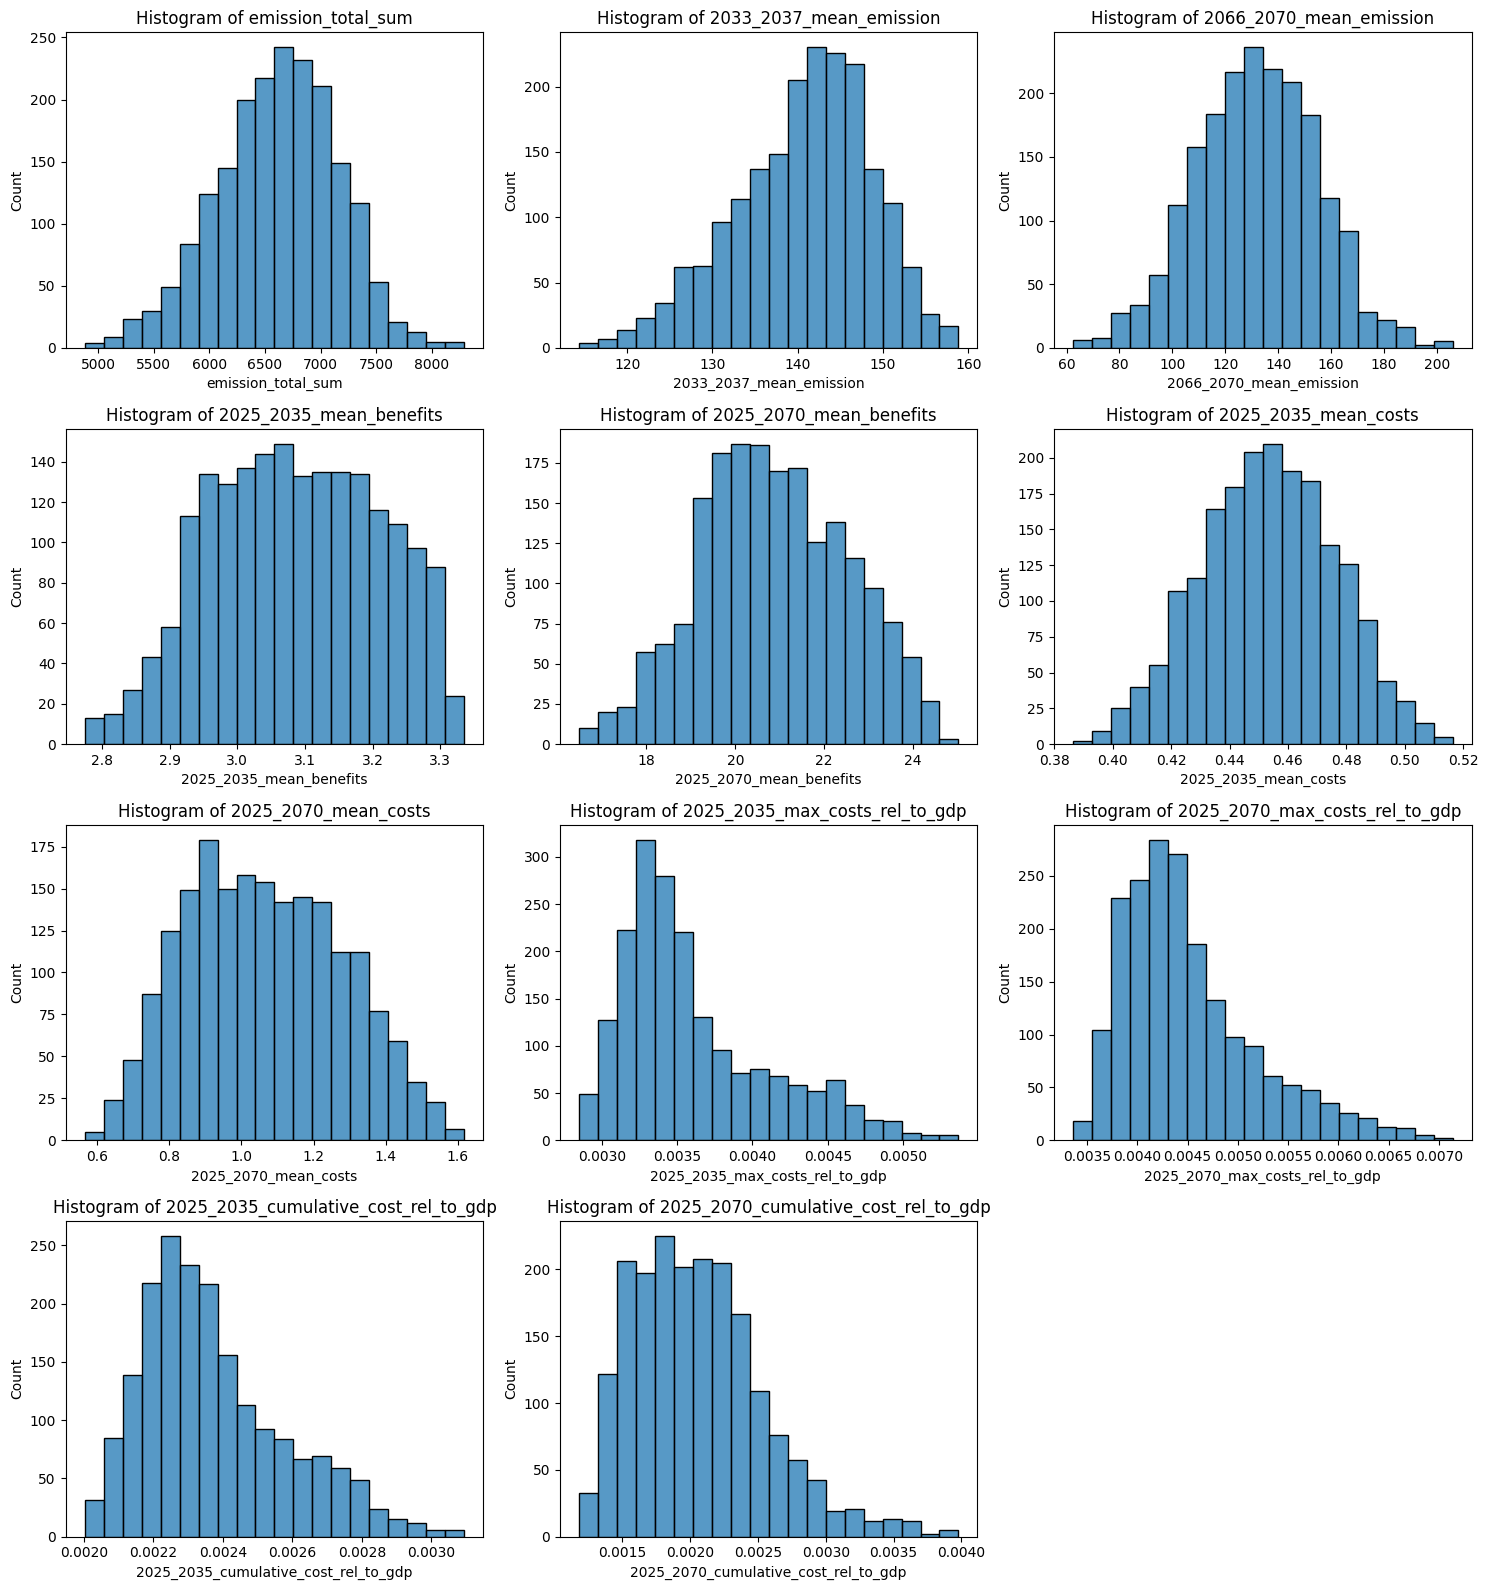

In [15]:
edau.plot_multiple_histograms(training_df, target_col, bins=20, kde=False)
                              

In [16]:

for col in target_col:
    edau.get_target_var_corr(training_df, col, exclude_cols=target_col)


Correlation with target variable 'emission_total_sum' (threshold: 0.1):
--------------------------------------------------
group_34_L_SCOE Fraction Heat Energy Demand  : 0.4181
group_60_X_exports             : 0.4120
group_66_X_elasticity_scoe_enerdem_per : 0.4100
group_64_X_elasticity_ippu_product_use : 0.4093
group_63_X_elasticity_ippu     : 0.4028
group_61_X_cost_enfu_fuel      : 0.4026
group_67_X_elasticity_trde_mtkm_to_gdp_freight : 0.4009
group_68_X_elasticity_trde_pkm_to_gdppc : 0.3961
group_65_X_population_gnrl     : 0.3710
group_62_X_gdp_mmm_usd         : 0.2850
group_27_L_:math:\text{CH}_4 Enteric Fermentation Emission Factor : 0.2677
group_19_L_Unadjusted Land Use Transition Probability : 0.2675
group_31_L_SCOE Heat Energy Demand Scalar : 0.1832
group_29_L_Fraction Eating Red Meat : 0.1826
group_58_L_Fraction of Non-Recycled Solid Waste  : 0.1339


Correlation with target variable '2033_2037_mean_emission' (threshold: 0.1):
--------------------------------------------------

In [17]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, method="iqr", factor=1.5)
print("Outlier percentages:", outliers)
outliers = edau.find_outlier_columns(training_df, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_total_sum': 0.67, '2033_2037_mean_emission': 0.83, '2066_2070_mean_emission': 0.47, '2025_2035_mean_costs': 0.05, '2025_2035_max_costs_rel_to_gdp': 2.74, '2025_2070_max_costs_rel_to_gdp': 3.47, '2025_2035_cumulative_cost_rel_to_gdp': 1.86, '2025_2070_cumulative_cost_rel_to_gdp': 2.12}
Outlier percentages: {'emission_total_sum': 0.21, '2033_2037_mean_emission': 0.21, '2066_2070_mean_emission': 0.36, '2025_2035_max_costs_rel_to_gdp': 0.62, '2025_2070_max_costs_rel_to_gdp': 1.09, '2025_2035_cumulative_cost_rel_to_gdp': 0.57, '2025_2070_cumulative_cost_rel_to_gdp': 1.24}


## Data Cleaning

In [18]:
dcu = DataCleaningUtils()

In [19]:
training_df.shape

(1933, 79)

In [20]:
# # Check those -inf values in technical_cost
# technical_cost_neg_inf = training_df[training_df["technical_cost"] == -np.inf]
# technical_cost_neg_inf

In [21]:
# # filter out -inf values in technical_cost
# training_df = training_df[training_df["technical_cost"] != -np.inf]
# training_df.shape

In [22]:
training_df_cleaned = dcu.remove_outliers(training_df, method="zscore", z_thresh=3.0)
print("Shape before removing outliers:", training_df.shape)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape before removing outliers: (1933, 79)
Shape after removing outliers: (1890, 79)


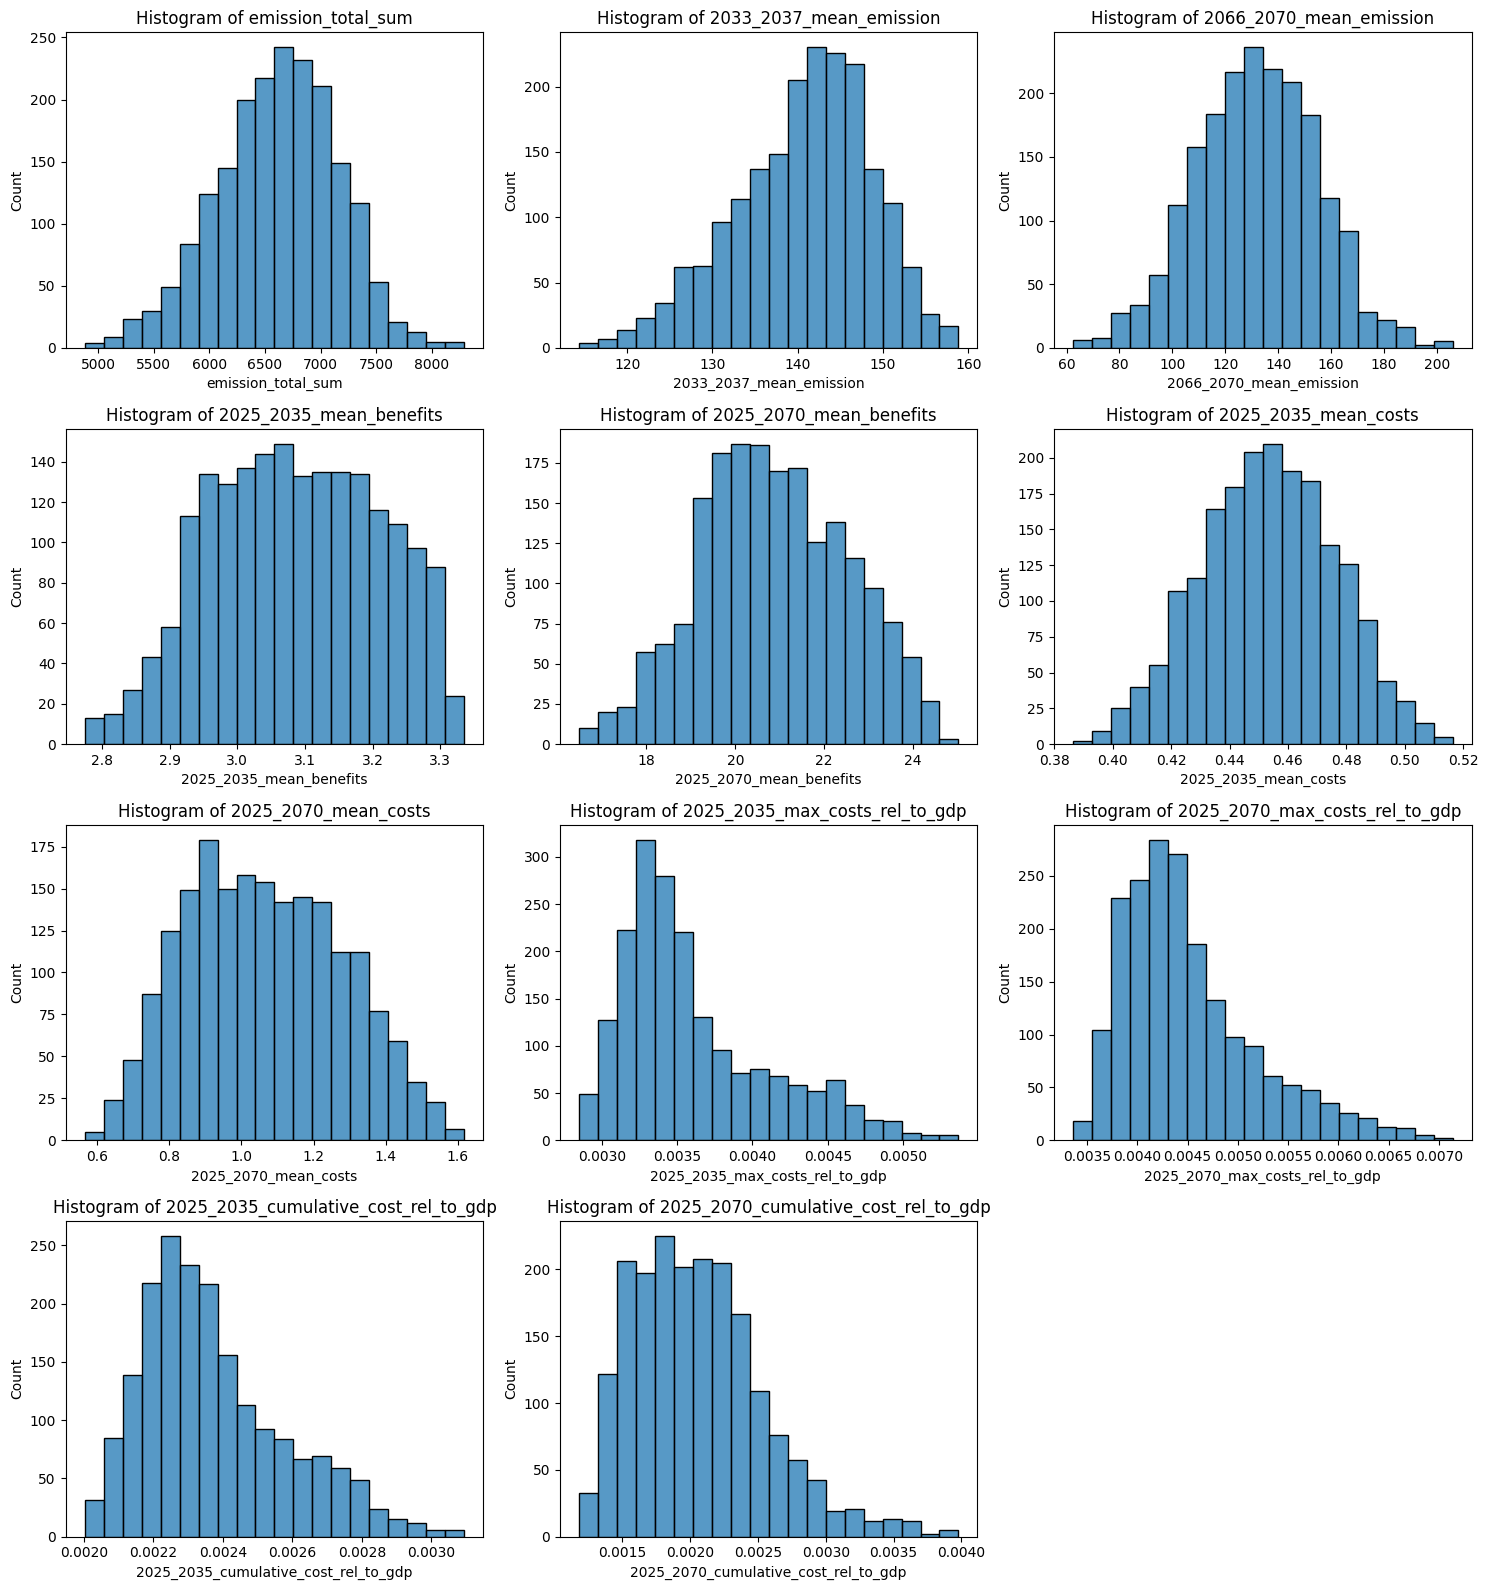

In [23]:
edau.plot_multiple_histograms(training_df, target_col, bins=20, kde=False)

In [24]:
outliers = edau.find_outlier_columns(training_df_cleaned, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'2033_2037_mean_emission': 0.21, '2025_2035_max_costs_rel_to_gdp': 0.26, '2025_2070_max_costs_rel_to_gdp': 0.69, '2025_2035_cumulative_cost_rel_to_gdp': 0.21, '2025_2070_cumulative_cost_rel_to_gdp': 0.16}


In [25]:
for col in target_col:
    edau.get_target_var_corr(training_df_cleaned, col, exclude_cols=target_col)


Correlation with target variable 'emission_total_sum' (threshold: 0.1):
--------------------------------------------------
group_34_L_SCOE Fraction Heat Energy Demand  : 0.4254
group_60_X_exports             : 0.4085
group_64_X_elasticity_ippu_product_use : 0.4051
group_66_X_elasticity_scoe_enerdem_per : 0.4042
group_61_X_cost_enfu_fuel      : 0.3974
group_67_X_elasticity_trde_mtkm_to_gdp_freight : 0.3935
group_68_X_elasticity_trde_pkm_to_gdppc : 0.3919
group_63_X_elasticity_ippu     : 0.3914
group_65_X_population_gnrl     : 0.3664
group_62_X_gdp_mmm_usd         : 0.2894
group_27_L_:math:\text{CH}_4 Enteric Fermentation Emission Factor : 0.2645
group_19_L_Unadjusted Land Use Transition Probability : 0.2640
group_31_L_SCOE Heat Energy Demand Scalar : 0.1902
group_29_L_Fraction Eating Red Meat : 0.1768
group_58_L_Fraction of Non-Recycled Solid Waste  : 0.1294


Correlation with target variable '2033_2037_mean_emission' (threshold: 0.1):
--------------------------------------------------

In [26]:
# edau.plot_multiple_histograms(training_df_cleaned, training_df_cleaned.drop(columns=["emission_total"]).columns.tolist(), bins=30, kde=False)

In [27]:
# training_df_cleaned[target_cols].describe()

In [28]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [29]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML


=== XGB (TEST results) ===
emission_total_sum             → MAE: 146.8456 | RMSE: 182.7987 | R²: 0.8900 | SMAPE: 2.2%
2033_2037_mean_emission        → MAE: 1.4471 | RMSE: 1.8500 | R²: 0.9482 | SMAPE: 1.0%
2066_2070_mean_emission        → MAE: 6.7321 | RMSE: 8.6131 | R²: 0.8627 | SMAPE: 5.3%
2025_2035_mean_benefits        → MAE: 0.0055 | RMSE: 0.0086 | R²: 0.9952 | SMAPE: 0.2%
2025_2070_mean_benefits        → MAE: 0.1071 | RMSE: 0.1635 | R²: 0.9906 | SMAPE: 0.5%
2025_2035_mean_costs           → MAE: 0.0032 | RMSE: 0.0041 | R²: 0.9694 | SMAPE: 0.7%
2025_2070_mean_costs           → MAE: 0.0237 | RMSE: 0.0312 | R²: 0.9805 | SMAPE: 2.2%
2025_2035_max_costs_rel_to_gdp → MAE: 0.0001 | RMSE: 0.0001 | R²: 0.9556 | SMAPE: 2.0%
2025_2070_max_costs_rel_to_gdp → MAE: 0.0001 | RMSE: 0.0001 | R²: 0.9558 | SMAPE: 2.1%
2025_2035_cumulative_cost_rel_to_gdp → MAE: 0.0001 | RMSE: 0.0001 | R²: 0.8285 | SMAPE: 2.7%
2025_2070_cumulative_cost_rel_to_gdp → MAE: 0.0001 | RMSE: 0.0001 | R²: 0.9254 | SMAPE: 4.6%

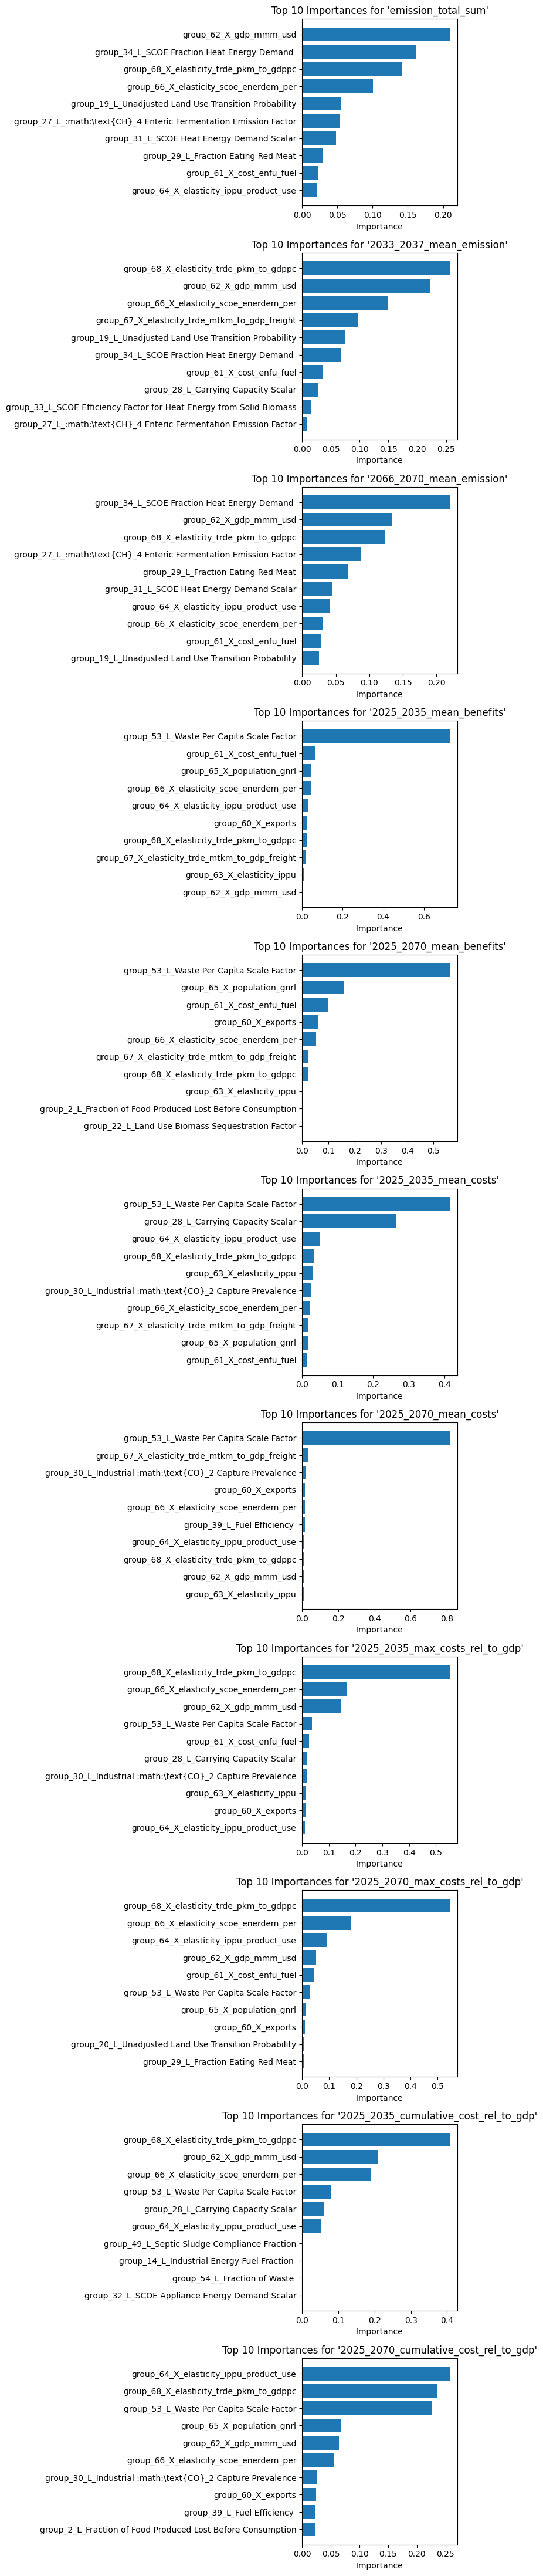

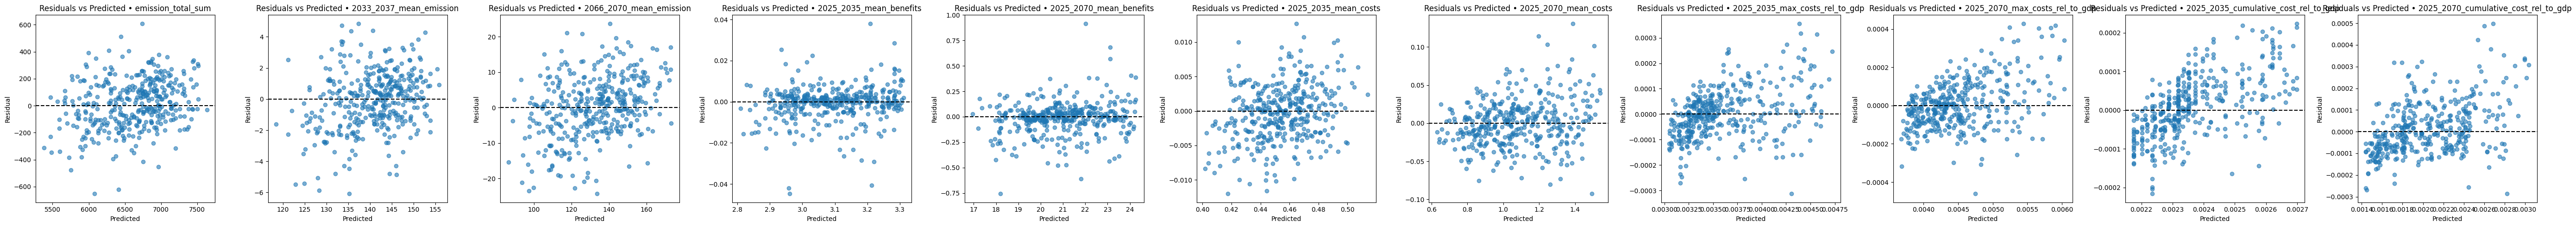

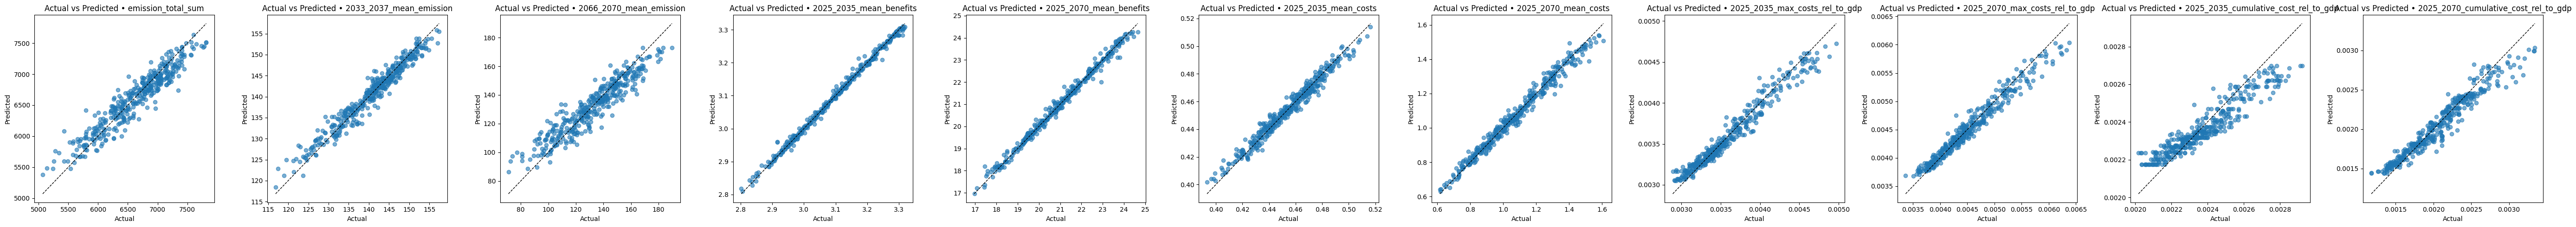

In [30]:
mulp = XGBMultiOutputPipeline(df=training_df_cleaned, targets=target_col)
mulp.run(tune=False, log_transform=False, plot_figures=True)

## Save the trained and tuned model and use it to predict new data

In [31]:
training_df_cleaned.head()

,group_2_L_Fraction of Food Produced Lost Before Consumption,group_12_L_Average Industrial Energy Fuel Efficiency Factor,group_35_L_Liming Demand Scalar,group_20_L_Unadjusted Land Use Transition Probability,group_57_L_Fraction of,group_60_X_exports,group_15_L_Clinker Fraction of Cement,group_3_L_,group_37_L_Transportation Demand Scalar,group_48_L_Biogas Recovery Factor at Wastewater Treatment Plants,...,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp,2025_2035_cumulative_cost_rel_to_gdp,2025_2070_cumulative_cost_rel_to_gdp
0,0.526063,0.300703,0.770088,0.302988,0.102412,-1.0,0.314034,0.244025,0.563116,0.391066,...,155.943011,162.178247,2.934405,19.269972,0.448135,0.834822,0.003210,0.003797,0.002197,0.001412
1,0.838025,0.133524,0.386492,0.991171,0.646343,-1.0,0.558463,0.142412,0.846307,0.201058,...,148.164485,165.491078,3.086639,20.875301,0.450949,1.094102,0.003223,0.004213,0.002211,0.001851
2,0.712446,0.922478,0.527285,0.552461,0.324450,-1.0,0.962973,0.229522,0.334866,0.184524,...,149.924342,167.532309,3.027576,20.253282,0.455116,0.946547,0.003264,0.003950,0.002231,0.001601
3,0.421732,0.813266,0.606331,0.490412,0.837631,-1.0,0.163575,0.895763,0.792520,0.467632,...,155.716764,171.095935,3.027648,20.315354,0.473642,1.031214,0.003431,0.004125,0.002322,0.001745
4,0.793248,0.569673,0.573831,0.598909,0.374262,-1.0,0.483057,0.963519,0.363667,0.996007,...,142.184124,152.521376,3.009067,20.038498,0.420872,0.882343,0.002963,0.003828,0.002063,0.001493


In [32]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(columns="emission_total")
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_2_L_Fraction of Food Produced Lost Before Consumption,group_12_L_Average Industrial Energy Fuel Efficiency Factor,group_35_L_Liming Demand Scalar,group_20_L_Unadjusted Land Use Transition Probability,group_57_L_Fraction of,group_60_X_exports,group_15_L_Clinker Fraction of Cement,group_3_L_,group_37_L_Transportation Demand Scalar,group_48_L_Biogas Recovery Factor at Wastewater Treatment Plants,...,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp,2025_2035_cumulative_cost_rel_to_gdp,2025_2070_cumulative_cost_rel_to_gdp
0,0.526063,0.300703,0.770088,0.302988,0.102412,-1.0,0.314034,0.244025,0.563116,0.391066,...,155.943011,162.178247,2.934405,19.269972,0.448135,0.834822,0.00321,0.003797,0.002197,0.001412


In [33]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
predictions

Predictions for single row:


,emission_total_sum,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp,2025_2035_cumulative_cost_rel_to_gdp,2025_2070_cumulative_cost_rel_to_gdp
0,7434.42627,155.940704,162.083359,2.933216,19.270712,0.448479,0.835731,0.003254,0.003861,0.002262,0.00153


In [34]:
print("Original values:")
print(training_df_cleaned.iloc[0][target_col])

Original values:
emission_total_sum                      7431.303667
2033_2037_mean_emission                  155.943011
2066_2070_mean_emission                  162.178247
2025_2035_mean_benefits                    2.934405
2025_2070_mean_benefits                   19.269972
2025_2035_mean_costs                       0.448135
2025_2070_mean_costs                       0.834822
2025_2035_max_costs_rel_to_gdp             0.003210
2025_2070_max_costs_rel_to_gdp             0.003797
2025_2035_cumulative_cost_rel_to_gdp       0.002197
2025_2070_cumulative_cost_rel_to_gdp       0.001412
Name: 0, dtype: float64


In [35]:
# Save the trained model
xgb_pipeline = mulp.pipeline  # only one now
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = f"xgb_pipeline_{RUN_ID}.pkl"
os.makedirs(TRAINED_MODELS_DIR, exist_ok=True)
overwrite_existing_model = True  # Set to True to overwrite existing model

MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
if os.path.exists(MODEL_PATH) and not overwrite_existing_model:
    print(f"Model {model_file_name} already exists at {MODEL_PATH}. Skipping save.")
else:
    print(f"Saving model to {MODEL_PATH} ...")
    joblib.dump(xgb_pipeline, MODEL_PATH)
    print("✅ Model saved successfully.")

Saving model to /Users/tony/Documents/sisepuede_modeling/ssp_uganda_data/metamodel/surrogate_model/trained_models/xgb_pipeline_1770771448.pkl ...
✅ Model saved successfully.


In [36]:
# Load the trained model and test predictions
xgb_pipeline_loaded = joblib.load(MODEL_PATH)

In [37]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
predictions

Predictions for single row:


,emission_total_sum,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp,2025_2035_cumulative_cost_rel_to_gdp,2025_2070_cumulative_cost_rel_to_gdp
0,7434.42627,155.940704,162.083359,2.933216,19.270712,0.448479,0.835731,0.003254,0.003861,0.002262,0.00153


In [38]:
print("Original values:")
training_df_cleaned.iloc[0][target_col]

Original values:


emission_total_sum                      7431.303667
2033_2037_mean_emission                  155.943011
2066_2070_mean_emission                  162.178247
2025_2035_mean_benefits                    2.934405
2025_2070_mean_benefits                   19.269972
2025_2035_mean_costs                       0.448135
2025_2070_mean_costs                       0.834822
2025_2035_max_costs_rel_to_gdp             0.003210
2025_2070_max_costs_rel_to_gdp             0.003797
2025_2035_cumulative_cost_rel_to_gdp       0.002197
2025_2070_cumulative_cost_rel_to_gdp       0.001412
Name: 0, dtype: float64